# VIF Critic Training v4 — Diagnostic-First + Default LR Finder

This notebook follows the v2 diagnostic workflow and adds per-model LR finder runs
for the active ordinal heads (CORAL/CORN/EMD/SoftOrdinal).


# Config

In [ ]:
from pathlib import Path

import yaml

# Resolve repo root for config lookup
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "config" / "vif.yaml").is_file():
    _repo = _repo.parent

_cfg_path = _repo / "config" / "vif.yaml"
if not _cfg_path.is_file():
    raise FileNotFoundError(f"Could not locate config file: {_cfg_path}")

_vif_cfg = yaml.safe_load(_cfg_path.read_text())
_training_defaults = _vif_cfg["training"]
_scheduler_defaults = _training_defaults["scheduler"]
_lr_finder_defaults = _training_defaults["lr_finder"]

lr_finder_cfg = {
    "start_lr": _lr_finder_defaults["start_lr"],
    "end_lr": _lr_finder_defaults["end_lr"],
    "num_iter": _lr_finder_defaults["num_iter"],
    "output_dir": "models/vif/lr_find_ordinal_v4",
}
if "max_selected_lr" in _lr_finder_defaults:
    lr_finder_cfg["max_selected_lr"] = _lr_finder_defaults["max_selected_lr"]

CONFIG = {
    # Encoder
    "encoder_model": "nomic-ai/nomic-embed-text-v1.5",
    "trust_remote_code": True,
    "truncate_dim": 256,  # Matryoshka truncation (MTEB 61.04 @ 256d)
    "text_prefix": "classification: ",  # Required task prefix for nomic models
    # Models to compare (previous 4 frontier runs + CDW-CE alpha sweep)
    "models_to_train": [
        "CORAL",
        "CORN",
        "EMD",
        "SoftOrdinal",
        "CDWCE_a2",
        "CDWCE_a3",
        "CDWCE_a5",
    ],
    "cdw_ce_alphas": [2, 3, 5],
    # Model
    "hidden_dim": 64,
    "dropout": 0.3,
    # Optimizer / training (sourced from config/vif.yaml)
    "learning_rate": _training_defaults["learning_rate"],
    "weight_decay": _training_defaults["weight_decay"],
    "batch_size": _training_defaults["batch_size"],
    "epochs": _training_defaults["epochs"],
    # Early stopping
    "early_stopping_patience": _training_defaults["early_stopping"]["patience"],
    "early_stopping_min_delta": _training_defaults["early_stopping"]["min_delta"],
    # LR scheduler
    "scheduler_factor": _scheduler_defaults["factor"],
    "scheduler_patience": _scheduler_defaults["patience"],
    "scheduler_min_lr": _scheduler_defaults["min_lr"],
    # State encoder
    "window_size": 1,
    # MC Dropout
    "mc_dropout_samples": 50,
    # Data splits
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "seed": 2025,
    # LR finder config (enabled for all models in this sweep)
    "use_lr_finder": True,
    "lr_finder": lr_finder_cfg,
}

print("=" * 50)
print("CONFIGURATION")
print("=" * 50)
for key, value in CONFIG.items():
    print(f"  {key:<30s} {str(value):>15s}")
print("=" * 50)


CONFIGURATION
  encoder_model                  nomic-ai/nomic-embed-text-v1.5
  trust_remote_code                         True
  truncate_dim                               256
  text_prefix                    classification: 
  models_to_train                ['CORAL', 'CORN', 'EMD', 'SoftOrdinal', 'CDWCE_a2', 'CDWCE_a3', 'CDWCE_a5']
  cdw_ce_alphas                        [2, 3, 5]
  hidden_dim                                  64
  dropout                                    0.3
  learning_rate                            0.001
  weight_decay                              0.01
  batch_size                                  16
  epochs                                     100
  early_stopping_patience                     20
  early_stopping_min_delta                 0.001
  scheduler_factor                           0.5
  scheduler_patience                          10
  scheduler_min_lr                         1e-05
  window_size                                  1
  mc_dropout_samples        

# Import Libs

In [ ]:
import os
import sys
from functools import partial
from pathlib import Path

# Walk up to find project root (contains src/ and pyproject.toml)
_dir = Path.cwd()
while _dir != _dir.parent:
    if (_dir / "src").is_dir() and (_dir / "pyproject.toml").is_file():
        os.chdir(_dir)
        break
    _dir = _dir.parent
sys.path.insert(0, ".")

import json
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Ensure inline plotting in notebooks (prevents stale non-inline backend state)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

from src.vif.dataset import (
    load_all_data,
    split_by_persona,
    merge_labels_and_entries,
    VIFDataset,
)
from src.vif.encoders import SBERTEncoder
from src.vif.state_encoder import StateEncoder
from src.vif.critic_ordinal import (
    CriticMLPCORAL,
    coral_loss_multi,
    CriticMLPCORN,
    corn_loss_multi,
    CriticMLPEMD,
    emd_loss_multi,
    CriticMLPCDWCE,
    cdw_ce_loss_multi,
    CriticMLPSoftOrdinal,
    soft_ordinal_loss_multi,
)
from src.vif.eval import (
    evaluate_with_uncertainty,
    format_results_table,
    discretize_predictions,
)
from src.vif.lr_finder import run_lr_finder
from src.models.judge import SCHWARTZ_VALUE_ORDER

# Reproducibility
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

# Device selection (v2-compatible)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Working directory: {os.getcwd()}")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Schwartz dimensions: {len(SCHWARTZ_VALUE_ORDER)}")


Working directory: /Users/desmondchoy/Projects/twinkl
Device: mps
PyTorch: 2.9.1
Schwartz dimensions: 10


/Users/desmondchoy/Projects/twinkl/.venv/lib/python3.12/site-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Section 1: Data Quality Audit (Issue #10)

**Issue #10 — Class Imbalance:**: Most Schwartz dimensions are neutral-dominated.
The model may learn to predict `0` for everything and still achieve high accuracy.
This section quantifies the imbalance and flags dimensions that may be unlearnable.

* `labels_df` - judge-assigned alignment scores
* `entries_df` - journal text

In [3]:
labels_df, entries_df = load_all_data()
merged_df = merge_labels_and_entries(labels_df, entries_df)

print(f"Labels shape:  {labels_df.shape}")
print(f"Entries shape: {entries_df.shape}")
print(f"Merged shape:  {merged_df.shape}")
print(f"Unique personas: {merged_df.select('persona_id').n_unique()}")


Labels shape:  (1460, 15)
Entries shape: (1460, 8)
Merged shape:  (1460, 21)
Unique personas: 180


In [4]:
labels_df.head().glimpse()

Rows: 5
Columns: 15
$ persona_id                     <str> '013d8101', '013d8101', '013d8101', '019235dc', '019235dc'
$ t_index                        <i64> 0, 1, 2, 0, 1
$ date                           <str> '2025-12-01', '2025-12-11', '2025-12-20', '2025-01-15', '2025-01-15'
$ alignment_vector         <list[i64]> [0, 0, 0, 0, 0, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 1, 0], [0, -1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
$ alignment_self_direction       <i64> 0, 0, 0, 0, 0
$ alignment_stimulation          <i64> 0, 0, -1, 0, 0
$ alignment_hedonism             <i64> 0, 0, 0, 0, 0
$ alignment_achievement          <i64> 0, 0, 0, 1, 1
$ alignment_power                <i64> 0, 0, 0, 1, 0
$ alignment_security             <i64> 1, 1, 1, 0, 0
$ alignment_conformity           <i64> 1, 0, 0, 0, 0
$ alignment_tradition            <i64> 0, 0, 0, 0, 0
$ alignment_benevolence          <i64> 0, 1, 0, 0, 1
$ alignment_universalism         <i64> 0, 0,

In [5]:
entries_df.head().glimpse()

Rows: 5
Columns: 8
$ persona_id          <str> '013d8101', '013d8101', '013d8101', '019235dc', '019235dc'
$ persona_name        <str> 'Emma Lindqvist', 'Emma Lindqvist', 'Emma Lindqvist', 'Megan Torres', 'Megan Torres'
$ core_values   <list[str]> ['Security'], ['Security'], ['Security'], ['Achievement', 'Benevolence'], ['Achievement', 'Benevolence']
$ t_index             <i64> 0, 1, 2, 0, 1
$ date                <str> '2025-12-01', '2025-12-11', '2025-12-20', '2025-01-15', '2025-01-15'
$ initial_entry       <str> 'Parent-teacher conferences tomorrow and I keep running through the talking points in my head. Mikkel says I over-prepare but I would rather have every answer ready than stumble in front of someone asking about their child.', 'The school announced budget cuts today and there were some worried faces in the staff room. I felt steady, actually. My position is permanent and I have been here longer than most.', 'Mikkel brought up the idea of moving to Berlin again at dinner. His co

In [6]:
dropped_label_rows = labels_df.height - merged_df.height
if dropped_label_rows > 0:
    print(f"Dropped label rows after merge: {dropped_label_rows}")
    key_options = [
        ["persona_id", "t_index"],
        ["entry_id"],
    ]
    for keys in key_options:
        if all(k in labels_df.columns for k in keys) and all(
            k in merged_df.columns for k in keys
        ):
            labels_keys = labels_df.select(keys).unique()
            merged_keys = merged_df.select(keys).unique()
            dropped_keys = labels_keys.join(merged_keys, on=keys, how="anti")
            print(f"  Missing key rows by {keys}: {dropped_keys.height}")
            if dropped_keys.height > 0:
                print(dropped_keys.head(5))
            break

print(
    f"\nLabel columns: {[c for c in labels_df.columns if c.startswith('alignment_')]}"
)
print(
    f"\nEntry text columns: {[c for c in entries_df.columns if c not in labels_df.columns]}"
)


Label columns: ['alignment_vector', 'alignment_self_direction', 'alignment_stimulation', 'alignment_hedonism', 'alignment_achievement', 'alignment_power', 'alignment_security', 'alignment_conformity', 'alignment_tradition', 'alignment_benevolence', 'alignment_universalism']

Entry text columns: ['persona_name', 'core_values', 'initial_entry', 'nudge_text', 'response_text']


## Class Distribution per Dimension

In [7]:
n_dims = len(SCHWARTZ_VALUE_ORDER)
distribution = np.zeros((n_dims, 3), dtype=int)  # rows=dims, cols=[-1, 0, +1]
class_labels = [-1, 0, 1]

for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    col = f"alignment_{dim}"
    series = merged_df.select(col).to_series()
    for j, val in enumerate(class_labels):
        distribution[i, j] = int((series == val).sum())

# Compute imbalance ratios
imbalance_ratios = []
for i in range(n_dims):
    row = distribution[i]
    ratio = float("inf") if (row == 0).any() else row.max() / row.min()
    imbalance_ratios.append(ratio)

# Print table
print(f"{'Dimension':<20s} {'-1':>6s} {'0':>6s} {'+1':>6s} {'Ratio':>8s} {'Flag':>8s}")
print("-" * 55)
for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    flag = ">10x" if imbalance_ratios[i] > 10 else ""
    print(
        f"{dim:<20s} {distribution[i, 0]:>6d} {distribution[i, 1]:>6d} {distribution[i, 2]:>6d} {imbalance_ratios[i]:>8.1f} {flag:>8s}"
    )

neutral_pct = distribution[:, 1].sum() / distribution.sum() * 100
print(f"\nOverall neutral %: {neutral_pct:.1f}%")

Dimension                -1      0     +1    Ratio     Flag
-------------------------------------------------------
self_direction          204    859    397      4.2         
stimulation              51   1282    127     25.1     >10x
hedonism                117   1185    158     10.1     >10x
achievement              81    988    391     12.2     >10x
power                   121   1187    152      9.8         
security                136   1100    224      8.1         
conformity              126   1017    317      8.1         
tradition                58   1148    254     19.8     >10x
benevolence             120    912    428      7.6         
universalism             56   1246    158     22.2     >10x

Overall neutral %: 74.8%


Heatmap:

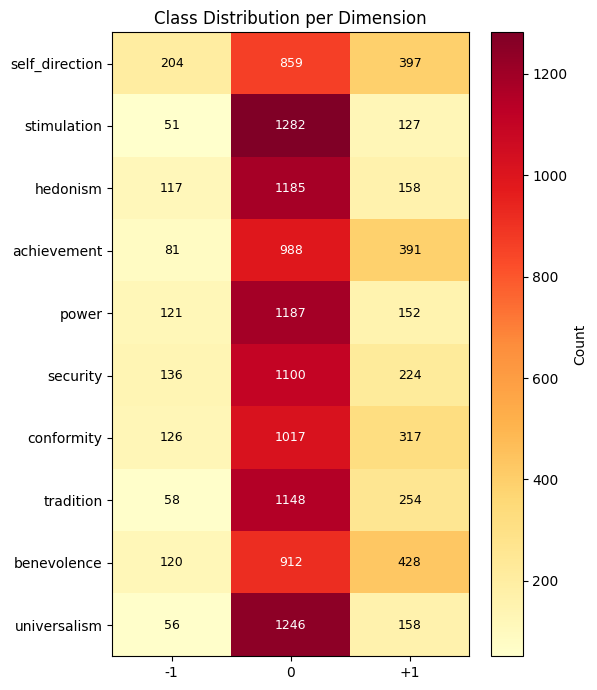

In [8]:
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(distribution, cmap="YlOrRd", aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["-1", "0", "+1"])
ax.set_yticks(range(n_dims))
ax.set_yticklabels(SCHWARTZ_VALUE_ORDER)
ax.set_title("Class Distribution per Dimension")
for i in range(n_dims):
    for j in range(3):
        color = "white" if distribution[i, j] > distribution.max() * 0.6 else "black"
        ax.text(
            j,
            i,
            str(distribution[i, j]),
            ha="center",
            va="center",
            fontsize=9,
            color=color,
        )
plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

Sparsity flags: Checking all dimensions where any class < 10 samples

In [9]:
MIN_SAMPLES = 10

print(f"{'Dimension':<20s} {'Min class':>10s} {'Min count':>10s} {'Status':>12s}")
print("-" * 55)
unlearnable = []
for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    min_idx = distribution[i].argmin()
    min_count = distribution[i, min_idx]
    min_class = class_labels[min_idx]
    status = "UNLEARNABLE" if min_count < MIN_SAMPLES else "OK"
    if min_count < MIN_SAMPLES:
        unlearnable.append(dim)
    print(f"{dim:<20s} {min_class:>10d} {min_count:>10d} {status:>12s}")

print(
    f"\nUnlearnable dims (any class < {MIN_SAMPLES} samples): {unlearnable if unlearnable else 'None'}"
)

Dimension             Min class  Min count       Status
-------------------------------------------------------
self_direction               -1        204           OK
stimulation                  -1         51           OK
hedonism                     -1        117           OK
achievement                  -1         81           OK
power                        -1        121           OK
security                     -1        136           OK
conformity                   -1        126           OK
tradition                    -1         58           OK
benevolence                  -1        120           OK
universalism                 -1         56           OK

Unlearnable dims (any class < 10 samples): None


# Section 2: Embedding Quality Probe (Issue #14)


**Issue #14 — Embedding Quality:** Are SBERT embeddings discriminative enough for value alignment? Does truncation lose information from long entries?

This section probes the encoder without retraining.

In [10]:
text_encoder = SBERTEncoder(
    CONFIG["encoder_model"],
    trust_remote_code=CONFIG["trust_remote_code"],
    truncate_dim=CONFIG["truncate_dim"],
    text_prefix=CONFIG["text_prefix"],
)
state_encoder = StateEncoder(
    text_encoder,
    window_size=CONFIG["window_size"],
)

print(f"Encoder: {text_encoder.model_name}")
print(f"Embedding dim: {text_encoder.embedding_dim}")
print(f"State dim: {state_encoder.state_dim}")

<All keys matched successfully>


Encoder: nomic-ai/nomic-embed-text-v1.5
Embedding dim: 256
State dim: 266


In [11]:
# Sample one random entry
rng = np.random.default_rng(CONFIG["seed"])
sample_idx = rng.integers(0, len(merged_df))
sample = merged_df.row(sample_idx, named=True)

print(f"\n{'=' * 60}")
print(f"RANDOM ENTRY VERIFICATION (row {sample_idx})")
print(f"{'=' * 60}")
print(f"persona_id:    {sample['persona_id']}")
print(f"persona_name:  {sample.get('persona_name', 'N/A')}")
print(f"core_values:   {sample.get('core_values', 'N/A')}")
print(f"date:          {sample['date']}")
print(f"t_index:       {sample['t_index']}")

print(f"\n--- initial_entry (first 200 chars) ---")
print(f"{(sample['initial_entry'] or '')[:200]}")
print(f"\n--- nudge_text (first 200 chars) ---")
print(f"{(sample['nudge_text'] or '')[:200]}")
print(f"\n--- response_text (first 200 chars) ---")
print(f"{(sample['response_text'] or '')[:200]}")


RANDOM ENTRY VERIFICATION (row 653)
persona_id:    70b51a5b
persona_name:  Meena Subramanian
core_values:   ['Power']
date:          2025-10-20
t_index:       6

--- initial_entry (first 200 chars) ---
Family WhatsApp group. Vikram posted photos of houses he and Priya are looking at in OMR — those new gated community flats near the IT corridor. Everyone started commenting, congratulating, sending em

--- nudge_text (first 200 chars) ---
What did the deleted messages say?

--- response_text (first 200 chars) ---
The first one asked why I'm always the last to know. The second one said something about respect. I deleted both because I knew Priya would read them too and it would become a whole thing.


Max context length: 8192 tokens

Token count statistics:
  Min:    18
  Mean:   200.8
  Median: 191.5
  P90:    342
  P95:    390
  Max:    709

Truncated entries: 0/1460 (0.0%)


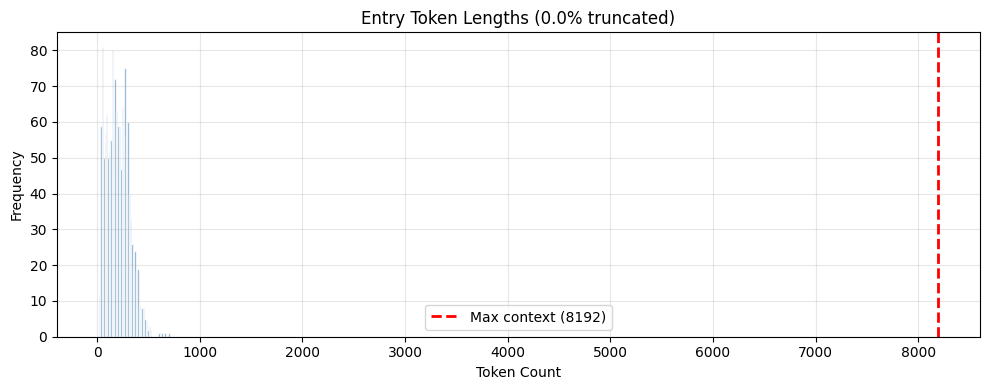

In [12]:
# Cell 2c — Entry length / truncation risk
tokenizer = text_encoder._model.tokenizer
max_seq_length = text_encoder._model.max_seq_length

all_texts = []
for row in merged_df.iter_rows(named=True):
    text = state_encoder.concatenate_entry_text(
        row["initial_entry"], row["nudge_text"], row["response_text"]
    )
    all_texts.append(text)

token_counts = []
for text in all_texts:
    tokens = tokenizer.encode(text, add_special_tokens=True)
    token_counts.append(len(tokens))

token_counts = np.array(token_counts)
n_truncated = (token_counts > max_seq_length).sum()
pct_truncated = n_truncated / len(token_counts) * 100

print(f"Max context length: {max_seq_length} tokens")
print(f"\nToken count statistics:")
print(f"  Min:    {token_counts.min()}")
print(f"  Mean:   {token_counts.mean():.1f}")
print(f"  Median: {np.median(token_counts):.1f}")
print(f"  P90:    {np.percentile(token_counts, 90):.0f}")
print(f"  P95:    {np.percentile(token_counts, 95):.0f}")
print(f"  Max:    {token_counts.max()}")
print(f"\nTruncated entries: {n_truncated}/{len(token_counts)} ({pct_truncated:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_counts, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(
    max_seq_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Max context ({max_seq_length})",
)
ax.set_xlabel("Token Count")
ax.set_ylabel("Frequency")
ax.set_title(f"Entry Token Lengths ({pct_truncated:.1f}% truncated)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 3: Model & Training (Issue #12)


**Issue #12 — Overfitting Risk:** the model has a very high parameter-to-sample ratio. This section quantifies the risk and monitors the training/validation gap.

In [ ]:
MODEL_CONFIGS = {
    "CORAL": {
        "class": CriticMLPCORAL,
        "loss_fn": coral_loss_multi,
        "is_ordinal": True,
    },
    "CORN": {
        "class": CriticMLPCORN,
        "loss_fn": corn_loss_multi,
        "is_ordinal": True,
    },
    "EMD": {
        "class": CriticMLPEMD,
        "loss_fn": emd_loss_multi,
        "is_ordinal": True,
    },
    "SoftOrdinal": {
        "class": CriticMLPSoftOrdinal,
        "loss_fn": soft_ordinal_loss_multi,
        "is_ordinal": True,
    },
    # CDW-CE alpha sweep
    "CDWCE_a2": {
        "class": CriticMLPCDWCE,
        "loss_fn": partial(cdw_ce_loss_multi, alpha=2),
        "is_ordinal": True,
    },
    "CDWCE_a3": {
        "class": CriticMLPCDWCE,
        "loss_fn": partial(cdw_ce_loss_multi, alpha=3),
        "is_ordinal": True,
    },
    "CDWCE_a5": {
        "class": CriticMLPCDWCE,
        "loss_fn": partial(cdw_ce_loss_multi, alpha=5),
        "is_ordinal": True,
    },
}


In [14]:
# Filter to active models
active_models = {
    k: dict(v) for k, v in MODEL_CONFIGS.items() if k in CONFIG["models_to_train"]
}

print(f"MODEL_CONFIGS defined: {list(MODEL_CONFIGS.keys())}")
print(f"models_to_train: {CONFIG['models_to_train']}")
print(f"Active models: {list(active_models.keys())}")


MODEL_CONFIGS defined: ['CORAL', 'CORN', 'EMD', 'SoftOrdinal', 'CDWCE_a2', 'CDWCE_a3', 'CDWCE_a5']
models_to_train: ['CORAL', 'CORN', 'EMD', 'SoftOrdinal', 'CDWCE_a2', 'CDWCE_a3', 'CDWCE_a5']
Active models: ['CORAL', 'CORN', 'EMD', 'SoftOrdinal', 'CDWCE_a2', 'CDWCE_a3', 'CDWCE_a5']


## Create datasets and dataloaders

In [15]:
print("Creating datasets (caching embeddings)...")
train_df, val_df, test_df = split_by_persona(
    labels_df,
    entries_df,
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"],
    seed=CONFIG["seed"],
)

train_dataset = VIFDataset(train_df, state_encoder, cache_embeddings=True)
val_dataset = VIFDataset(val_df, state_encoder, cache_embeddings=True)
test_dataset = VIFDataset(test_df, state_encoder, cache_embeddings=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

n_train = len(train_dataset)
n_val = len(val_dataset)
n_test = len(test_dataset)

print(f"\nSplit sizes:")
print(
    f"  Train: {n_train} samples ({train_df.select('persona_id').n_unique()} personas) -> {len(train_loader)} batches"
)
print(
    f"  Val:   {n_val} samples ({val_df.select('persona_id').n_unique()} personas) -> {len(val_loader)} batches"
)
print(
    f"  Test:  {n_test} samples ({test_df.select('persona_id').n_unique()} personas) -> {len(test_loader)} batches"
)

Creating datasets (caching embeddings)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Split sizes:
  Train: 1020 samples (125 personas) -> 64 batches
  Val:   230 samples (28 personas) -> 15 batches
  Test:  210 samples (27 personas) -> 14 batches


In [ ]:
# Active model validation (v4 frontier set)
if not active_models:
    raise ValueError(
        f"No valid models in models_to_train={CONFIG['models_to_train']}. "
        f"Valid names: {list(MODEL_CONFIGS.keys())}"
    )

print(f"Using ordinal models: {', '.join(active_models.keys())}")


Using ordinal models: CORAL, CORN, EMD, SoftOrdinal, CDWCE_a2, CDWCE_a3, CDWCE_a5


In [17]:
print(f"\n{'Model':<15s} {'Parameters':>12s} {'Output logits':>15s} {'Loss':>25s}")
print("-" * 70)
n_params = 0
for name, cfg in active_models.items():
    m = cfg["class"](
        input_dim=state_encoder.state_dim,
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"],
    )
    param_count = sum(param.numel() for param in m.parameters())
    n_params = max(n_params, param_count)
    n_out = m.fc_out.out_features
    loss_name = (
        cfg["loss_fn"].__class__.__name__
        if isinstance(cfg["loss_fn"], nn.Module)
        else getattr(
            cfg["loss_fn"],
            "__name__",
            getattr(cfg["loss_fn"], "func", cfg["loss_fn"]).__name__,
        )
    )
    print(f"{name:<15s} {param_count:>12,} {n_out:>15d} {loss_name:>25s}")
print("-" * 70)
print(f"\nMax parameters (for overfitting check): {n_params:,}")

# Overfitting risk check
param_sample_ratio = n_params / n_train
print(f"Parameters:       {n_params:,}")
print(f"Training samples: {n_train}")
print(f"Param/sample ratio: {param_sample_ratio:.1f}x")
print()
if param_sample_ratio > 100:
    print("SEVERE overfitting risk (>100x). Model will likely memorize training data.")
elif param_sample_ratio > 10:
    print("HIGH overfitting risk (>10x). Strong regularization essential.")
elif param_sample_ratio > 1:
    print("MODERATE overfitting risk (>1x). Monitor train/val gap carefully.")
else:
    print("Low overfitting risk (<1x).")


Model             Parameters   Output logits                      Loss
----------------------------------------------------------------------
CORAL                 22,804              20          coral_loss_multi
CORN                  22,804              20           corn_loss_multi
EMD                   23,454              30            emd_loss_multi
SoftOrdinal           23,454              30   soft_ordinal_loss_multi
CDWCE_a2              23,454              30         cdw_ce_loss_multi
CDWCE_a3              23,454              30         cdw_ce_loss_multi
CDWCE_a5              23,454              30         cdw_ce_loss_multi
----------------------------------------------------------------------

Max parameters (for overfitting check): 23,454
Parameters:       23,454
Training samples: 1020
Param/sample ratio: 23.0x

HIGH overfitting risk (>10x). Strong regularization essential.


In [ ]:
# Cell 3d - Multi-model training loop with optional per-model LR finder


def train_model(name, model_cfg, train_loader, val_loader, config, device):
    """Train a single model and return its best state + history.

    By default this uses LR finder output. For fixed-LR ablations, set
    config["use_lr_finder"] = False to use config["learning_rate"] directly.
    """
    # Per-model seed for reproducibility
    torch.manual_seed(config["seed"])
    np.random.seed(config["seed"])

    model = model_cfg["class"](
        input_dim=state_encoder.state_dim,
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    )
    model.to(device)

    loss_fn = model_cfg["loss_fn"]

    use_lr_finder = config.get("use_lr_finder", True)
    if use_lr_finder:
        lr_find_cfg = config.get("lr_finder", {})
        lr_output_dir = Path(
            lr_find_cfg.get("output_dir", "models/vif/lr_find_ordinal_v4")
        )
        lr_output_dir.mkdir(parents=True, exist_ok=True)
        history_snapshot_path = lr_output_dir / f"lr_find_{name}.json"

        lr_finder_result = run_lr_finder(
            model=model,
            train_loader=train_loader,
            criterion=loss_fn,
            configured_learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"],
            device=device,
            output_dir=lr_output_dir,
            start_lr=lr_find_cfg["start_lr"],
            end_lr=lr_find_cfg["end_lr"],
            num_iter=lr_find_cfg["num_iter"],
            max_selected_lr=lr_find_cfg.get("max_selected_lr"),
        )

        # Keep per-model LR history for visualization and remove notebook PNG artifacts.
        history_src = Path(lr_finder_result["artifacts"].get("history_path", ""))
        if history_src.is_file():
            history_snapshot_path.write_text(history_src.read_text())
            lr_finder_result["artifacts"]["history_path"] = str(history_snapshot_path)

        plot_path_str = lr_finder_result["artifacts"].get("plot_path")
        if plot_path_str:
            plot_src = Path(plot_path_str)
            if plot_src.is_file():
                plot_src.unlink()
        lr_finder_result["artifacts"]["plot_path"] = None

        selected_lr = lr_finder_result["lr_selected"]

        print(
            f"  LR finder -> lr_steep={lr_finder_result['suggestions']['lr_steep']}, "
            f"lr_valley={lr_finder_result['suggestions']['lr_valley']}, "
            f"selected={selected_lr}"
        )
        print(
            "  LR meta -> "
            f"strategy={lr_finder_result['suggestions'].get('valley_strategy')}, "
            f"source={lr_finder_result.get('lr_selected_source')}, "
            f"note={lr_finder_result.get('fallback_reason') or 'none'}"
        )
    else:
        selected_lr = config["learning_rate"]
        lr_finder_result = {
            "enabled": False,
            "params": None,
            "suggestions": {
                "lr_steep": None,
                "lr_valley": None,
                "valley_strategy": None,
                "valley_in_tail": None,
                "smoothed_drop_fraction": None,
                "is_mostly_monotonic": None,
            },
            "lr_selected": selected_lr,
            "lr_selected_source": "configured_learning_rate",
            "configured_learning_rate": config["learning_rate"],
            "fallback_reason": "lr_finder_disabled",
            "history_points": 0,
            "artifacts": {
                "plot_path": None,
                "history_path": None,
            },
        }
        print(f"  LR finder disabled -> using configured learning rate: {selected_lr}")

    optimizer = AdamW(
        model.parameters(),
        lr=selected_lr,
        weight_decay=config["weight_decay"],
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config["scheduler_factor"],
        patience=config["scheduler_patience"],
        min_lr=config["scheduler_min_lr"],
    )

    history = {"train_loss": [], "val_loss": [], "lr": []}
    best_val_loss = float("inf")
    best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    best_epoch = 0
    patience_counter = 0

    for epoch in range(config["epochs"]):
        # Train
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = model(batch_x)
            loss = loss_fn(output, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                output = model(batch_x)
                val_loss += loss_fn(output, batch_y).item()
        val_loss /= len(val_loader)

        if not np.isfinite(val_loss):
            print(f"  Epoch {epoch + 1:3d}: non-finite val_loss, stopping")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        if val_loss < best_val_loss - config["early_stopping_min_delta"]:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }
            patience_counter = 0
            if (epoch + 1) <= 3 or (epoch + 1) % 10 == 0:
                print(
                    f"  Epoch {epoch + 1:3d}: train={train_loss:.4f}, "
                    f"val={val_loss:.4f}, lr={current_lr:.6f} [BEST]"
                )
        else:
            patience_counter += 1
            if (epoch + 1) % 10 == 0:
                print(
                    f"  Epoch {epoch + 1:3d}: train={train_loss:.4f}, "
                    f"val={val_loss:.4f}, lr={current_lr:.6f}"
                )

        if patience_counter >= config["early_stopping_patience"]:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    # Restore best model
    model.load_state_dict(best_model_state)
    model.to(device)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "lr_finder": lr_finder_result,
        "learning_rate_applied": selected_lr,
    }


# Train all active models
trained_models = {}
skipped_models = {}
for name, cfg in active_models.items():
    print()
    print("=" * 70)
    print(f"Training {name}")
    print("=" * 70)
    result = train_model(name, cfg, train_loader, val_loader, CONFIG, device)
    n_epochs = len(result["history"]["train_loss"])
    if n_epochs == 0:
        skipped_models[name] = result
        print("  No valid epochs completed; excluding model from evaluation.")
        continue

    trained_models[name] = result
    print(
        f"  Best val loss: {result['best_val_loss']:.4f} "
        f"at epoch {result['best_epoch'] + 1}/{n_epochs}; "
        f"applied_lr={result['learning_rate_applied']:.6g}"
    )

if not trained_models:
    raise RuntimeError("No models completed any valid epochs. Check training logs.")

print()
print("=" * 70)
print(
    f"Training complete: {len(trained_models)} successful, "
    f"{len(skipped_models)} skipped"
)
print("=" * 70)



Training CORAL


  0%|          | 0/200 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
  LR finder -> lr_steep=0.0037399373024788007, lr_valley=0.019791668678535573, selected=0.019791668678535573
  LR meta -> strategy=valley_over_10, source=lr_valley, note=none
  Epoch   1: train=0.7680, val=0.6775, lr=0.019792 [BEST]
  Epoch   2: train=0.6963, val=0.5885, lr=0.019792 [BEST]
  Epoch   3: train=0.6244, val=0.5510, lr=0.019792 [BEST]
  Epoch  10: train=0.5065, val=0.4813, lr=0.019792 [BEST]
  Epoch  20: train=0.4284, val=0.4857, lr=0.019792
  Epoch  30: train=0.3444, val=0.5384, lr=0.009896
  Early stopping at epoch 36
  Best val loss: 0.4779 at epoch 16/36; applied_lr=0.0197917

Training CORN


  0%|          | 0/200 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
  LR finder -> lr_steep=0.0037399373024788007, lr_valley=0.009547716114208063, selected=0.009547716114208063
  LR meta -> strategy=valley_over_10, source=lr_valley, note=none
  Epoch   1: train=0.3869, val=0.3246, lr=0.009548 [BEST]
  Epoch   2: train=0.3271, val=0.2765, lr=0.009548 [BEST]
  Epoch   3: train=0.3016, val=0.2628, lr=0.009548 [BEST]
  Epoch  10: train=0.2365, val=0.2587, lr=0.009548
  Epoch  20: train=0.1851, val=0.2608, lr=0.004774
  Early stopping at epoch 27
  Best val loss: 0.2369 at epoch 7/27; applied_lr=0.00954772

Training EMD


...

Learning rate search finished. See the graph with {finder_name}.plot()
  LR finder -> lr_steep=0.0021214517849106303, lr_valley=0.0021214517849106303, selected=0.0021214517849106303
  LR meta -> strategy=fallback_lr_steep, source=lr_valley, note=none
  Epoch   1: train=0.7140, val=0.5923, lr=0.002121 [BEST]
  Epoch   2: train=0.6168, val=0.5243, lr=0.002121 [BEST]
  Epoch   3: train=0.5699, val=0.5114, lr=0.002121 [BEST]
  Epoch  10: train=0.4718, val=0.4571, lr=0.002121
  Epoch  20: train=0.4117, val=0.4759, lr=0.002121
  Epoch  30: train=0.3495, val=0.4771, lr=0.001061
  Early stopping at epoch 33
  Best val loss: 0.4498 at epoch 13/33; applied_lr=0.00212145

Training CDWCE_a3


  0%|          | 0/200 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
  LR finder -> lr_steep=0.0021214517849106303, lr_valley=0.015522253574270487, selected=0.015522253574270487
  LR meta -> strategy=valley_over_10, source=lr_valley, note=none
  Epoch   1: train=0.7604, val=0.6483, lr=0.015522 [BEST]
  Epoch   2: train=0.6924, val=0.6090, lr=0.015522 [BEST]
  Epoch   3: train=0.6734, val=0.5994, lr=0.015522 [BEST]
  Epoch  10: train=0.5672, val=0.5190, lr=0.015522
  Epoch  20: train=0.4929, val=0.5365, lr=0.007761
  Epoch  30: train=0.4086, val=0.5289, lr=0.007761
  Epoch  40: train=0.3545, val=0.5511, lr=0.003881
  Early stopping at epoch 41
  Best val loss: 0.4956 at epoch 21/41; applied_lr=0.0155223

Training CDWCE_a5


  0%|          | 0/200 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
  LR finder -> lr_steep=0.0023004301197729195, lr_valley=0.0023004301197729195, selected=0.0023004301197729195
  LR meta -> strategy=fallback_lr_steep, source=lr_valley, note=none
  Epoch   1: train=1.4761, val=0.8737, lr=0.002300 [BEST]
  Epoch   2: train=0.9666, val=0.8485, lr=0.002300 [BEST]
  Epoch   3: train=0.9439, val=0.8341, lr=0.002300 [BEST]
  Epoch  10: train=0.8109, val=0.7429, lr=0.002300 [BEST]
  Epoch  20: train=0.7098, val=0.7154, lr=0.002300
  Epoch  30: train=0.6258, val=0.6471, lr=0.002300 [BEST]
  Epoch  40: train=0.5579, val=0.8120, lr=0.002300
  Epoch  50: train=0.4726, val=0.7886, lr=0.001150
  Early stopping at epoch 50
  Best val loss: 0.6471 at epoch 30/50; applied_lr=0.00230043

Training complete: 7 successful, 0 skipped


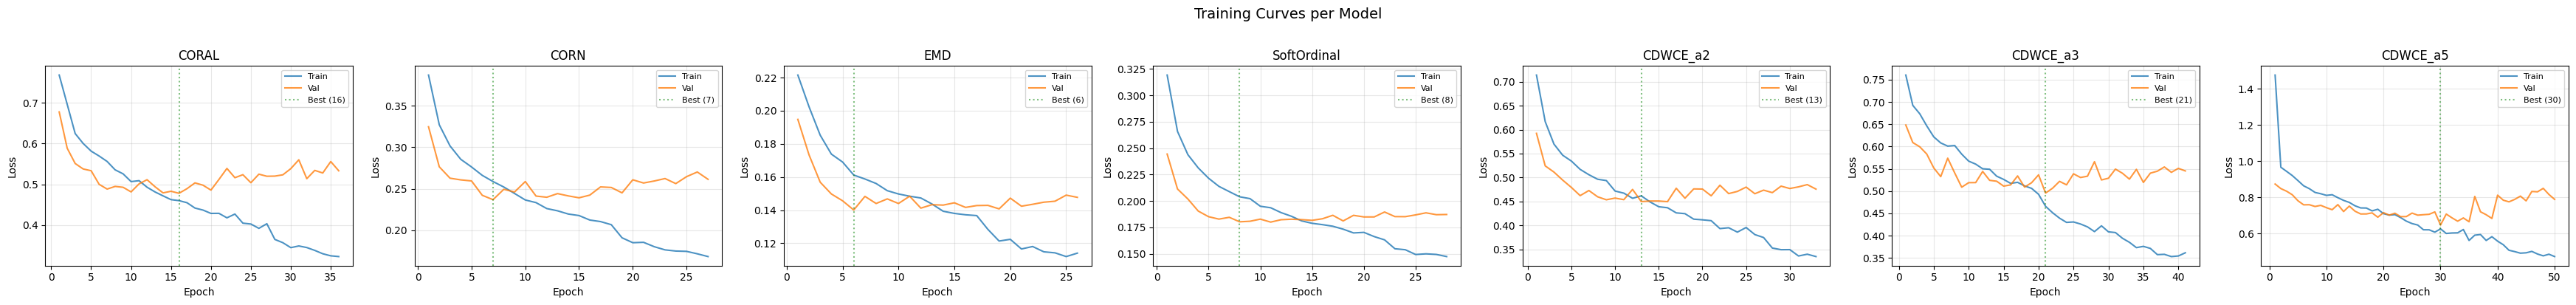


Model             Best epoch   Train loss     Val loss        Gap    LR(applied)     LR(source)
--------------------------------------------------------------------------------------------------
CORAL              16/36          0.4599       0.4779    +0.0180      0.0197917      lr_valley
CORN                7/27          0.2587       0.2369    -0.0218     0.00954772      lr_valley
EMD                 6/26          0.1612       0.1401    -0.0211      0.0197917      lr_valley
SoftOrdinal         8/28          0.2039       0.1803    -0.0237     0.00110975      lr_valley
CDWCE_a2           13/33          0.4617       0.4498    -0.0120     0.00212145      lr_valley
CDWCE_a3           21/41          0.4659       0.4956    +0.0297      0.0155223      lr_valley
CDWCE_a5           30/50          0.6258       0.6471    +0.0214     0.00230043      lr_valley


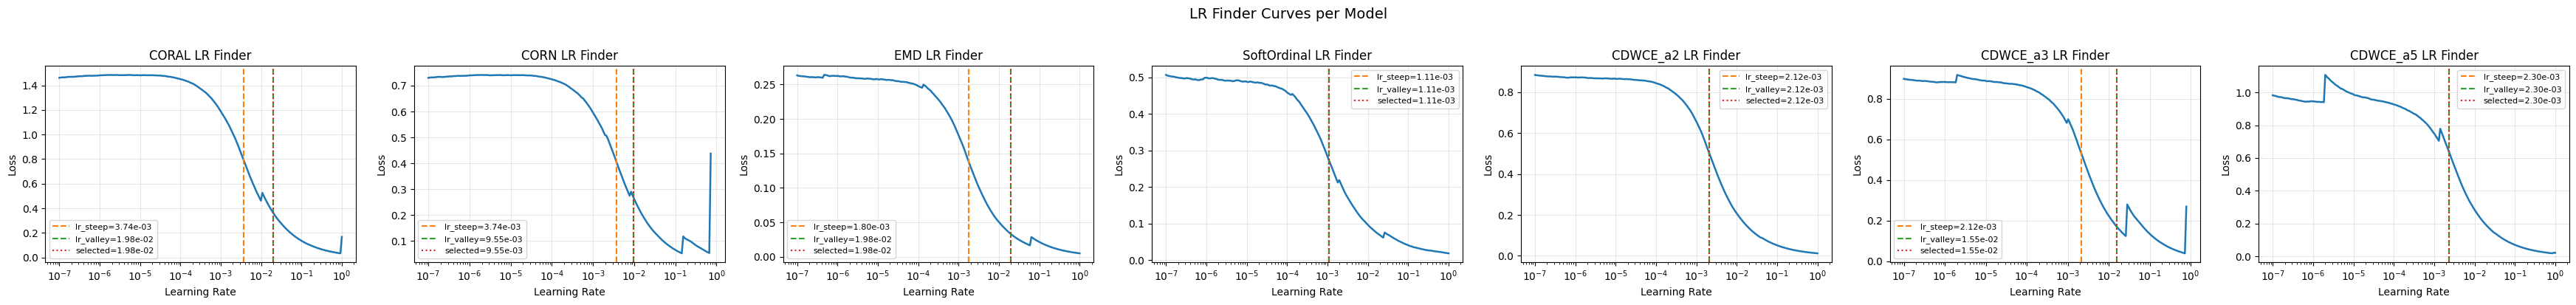

In [19]:
# Cell 3e - Training curves + LR finder curves (one subplot per model)
n_models = len(trained_models)
if n_models == 0:
    print("No models trained. Check training loop logs above.")
else:
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)
    axes = axes.flatten()

    for idx, (name, result) in enumerate(trained_models.items()):
        ax = axes[idx]
        history = result["history"]
        best_ep = result["best_epoch"]
        epochs_range = range(1, len(history["train_loss"]) + 1)

        ax.plot(epochs_range, history["train_loss"], label="Train", alpha=0.8)
        ax.plot(epochs_range, history["val_loss"], label="Val", alpha=0.8)
        if len(history["train_loss"]) > 0:
            ax.axvline(
                best_ep + 1,
                color="green",
                linestyle=":",
                alpha=0.5,
                label=f"Best ({best_ep + 1})",
            )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{name}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training Curves per Model", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary table
    print(
        f"\n{'Model':<15s} {'Best epoch':>12s} {'Train loss':>12s} {'Val loss':>12s} {'Gap':>10s} {'LR(applied)':>14s} {'LR(source)':>14s}"
    )
    print("-" * 98)
    for name, result in trained_models.items():
        h = result["history"]
        be = result["best_epoch"]
        n_ep = len(h["train_loss"])
        if n_ep == 0:
            print(
                f"{name:<15s} {'N/A':>12s} {'N/A':>12s} {'N/A':>12s} {'N/A':>10s} {'N/A':>14s} {'N/A':>14s}"
            )
            continue
        tl = h["train_loss"][be]
        vl = h["val_loss"][be]
        gap = vl - tl
        lr_applied = result.get("learning_rate_applied", float("nan"))
        lr_source = result.get("lr_finder", {}).get("lr_selected_source", "N/A")
        print(
            f"{name:<15s} {be + 1:>5d}/{n_ep:<5d} {tl:>12.4f} {vl:>12.4f} {gap:>+10.4f} {lr_applied:>14.6g} {lr_source:>14s}"
        )

    # LR finder curves
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)
    axes = axes.flatten()

    for idx, (name, result) in enumerate(trained_models.items()):
        ax = axes[idx]
        lr_meta = result.get("lr_finder", {})
        history_path = Path(lr_meta.get("artifacts", {}).get("history_path", ""))

        if not history_path.exists():
            ax.text(
                0.5,
                0.5,
                f"No LR history for {name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        history_json = json.loads(history_path.read_text())
        lrs = history_json.get("learning_rate", [])
        losses = history_json.get("loss", [])

        if not lrs or not losses:
            ax.text(
                0.5,
                0.5,
                f"No valid LR points for {name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        ax.plot(lrs, losses, linewidth=1.8)
        ax.set_xscale("log")
        ax.set_xlabel("Learning Rate")
        ax.set_ylabel("Loss")
        ax.set_title(f"{name} LR Finder")
        ax.grid(True, alpha=0.3)

        lr_steep = history_json.get("suggestions", {}).get("lr_steep")
        lr_valley = history_json.get("suggestions", {}).get("lr_valley")
        lr_selected = result.get("learning_rate_applied")
        if lr_steep is not None:
            ax.axvline(
                lr_steep,
                color="tab:orange",
                linestyle="--",
                label=f"lr_steep={lr_steep:.2e}",
            )
        if lr_valley is not None:
            ax.axvline(
                lr_valley,
                color="tab:green",
                linestyle="--",
                label=f"lr_valley={lr_valley:.2e}",
            )
        if lr_selected is not None:
            ax.axvline(
                lr_selected,
                color="tab:red",
                linestyle=":",
                label=f"selected={lr_selected:.2e}",
            )
        if lr_steep is not None or lr_valley is not None or lr_selected is not None:
            ax.legend(fontsize=8)

    plt.suptitle("LR Finder Curves per Model", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# Section 4: Evaluation Dashboard (Issues #10, #11)


**Issue #10 — Class Imbalance:** Does the model predict only neutrals?

This section provides confusion matrices and prediction distributions to diagnose class imbalance and hedging behavior.

In [20]:
# Cell 4a - Evaluate all models with MC Dropout uncertainty
all_results = {}
model_health = {}

for name, result in trained_models.items():
    model = result["model"]
    print(f"\n{'=' * 70}")
    print(f"Evaluating {name} with MC Dropout uncertainty...")
    print(f"{'=' * 70}")
    eval_result = evaluate_with_uncertainty(
        model,
        test_loader,
        n_mc_samples=CONFIG["mc_dropout_samples"],
        device=device,
        include_ordinal_metrics=True,
    )
    all_results[name] = eval_result
    print(f"\n{format_results_table(eval_result)}")

    preds = eval_result["predictions"]
    uncertainties = eval_result["uncertainties"]
    qwk_mean = float(eval_result.get("qwk_mean", float("nan")))
    spearman_mean = float(eval_result.get("spearman_mean", float("nan")))
    mean_uncertainty = float(
        eval_result["calibration"].get("mean_uncertainty", float("nan"))
    )
    hedging_mean = float(((preds > -0.3) & (preds < 0.3)).mean())
    prediction_std = float(np.std(preds))

    fail_reasons = []
    if not np.isfinite(qwk_mean):
        fail_reasons.append("qwk_nan")
    if not np.isfinite(spearman_mean):
        fail_reasons.append("spearman_nan")
    if mean_uncertainty < 1e-6:
        fail_reasons.append("uncertainty_collapse")
    if hedging_mean >= 0.98:
        fail_reasons.append("hedging_collapse")
    if prediction_std < 1e-6:
        fail_reasons.append("prediction_constant")

    model_health[name] = {
        "qwk_mean": qwk_mean,
        "spearman_mean": spearman_mean,
        "mean_uncertainty": mean_uncertainty,
        "hedging_mean": hedging_mean,
        "prediction_std": prediction_std,
        "fail_reasons": fail_reasons,
    }

if not all_results:
    raise RuntimeError("No models were evaluated successfully.")

print(f"\n{'=' * 70}")
print("Model Health Check")
print(f"{'=' * 70}")
print(
    f"{'Model':<15s} {'QWK':>8s} {'Spearman':>10s} {'Mean unc.':>10s} {'Hedging':>10s} {'Pred std':>10s}  Status"
)
print("-" * 98)
for name, health in model_health.items():
    qwk_str = f"{health['qwk_mean']:.3f}" if np.isfinite(health["qwk_mean"]) else "N/A"
    sp_str = (
        f"{health['spearman_mean']:.3f}"
        if np.isfinite(health["spearman_mean"])
        else "N/A"
    )
    status = (
        "OK"
        if not health["fail_reasons"]
        else f"EXCLUDE ({', '.join(health['fail_reasons'])})"
    )
    print(
        f"{name:<15s} {qwk_str:>8s} {sp_str:>10s} {health['mean_uncertainty']:>10.4f} "
        f"{health['hedging_mean']:>9.1%} {health['prediction_std']:>10.6f}  {status}"
    )

rankable_results = {
    name: all_results[name]
    for name, health in model_health.items()
    if not health["fail_reasons"]
}
excluded_models = [
    name for name, health in model_health.items() if health["fail_reasons"]
]

if not rankable_results:
    print(
        "\nWARNING: All models flagged as degenerate; using all_results for comparison tables."
    )
    rankable_results = dict(all_results)
elif excluded_models:
    print(f"\nExcluding from ranking/comparison: {excluded_models}")



Evaluating CORAL with MC Dropout uncertainty...

Dimension                   MAE   Spearman   Accuracy        QWK
----------------------------------------------------------------
self_direction           0.3957      0.477     66.67%      0.402
stimulation              0.0890      0.311     91.90%      0.538
hedonism                 0.1310      0.441     87.14%      0.410
achievement              0.1942      0.316     85.24%      0.415
power                    0.0854     -0.015     94.29%     -0.111
security                 0.3071      0.218     76.67%      0.230
conformity               0.2699      0.558     74.76%      0.507
tradition                0.1621      0.546     83.81%      0.279
benevolence              0.2257      0.542     78.57%      0.379
universalism             0.1943      0.488     82.86%      0.444
----------------------------------------------------------------
MEAN                     0.2054      0.388     82.19%      0.349

Calibration:
  Error-uncertainty correl

Model Comparison (rankable models):
shape: (7, 6)
┌─────────────┬────────┬──────────┬────────┬──────────┬─────────────┐
│ Model       ┆ MAE    ┆ Accuracy ┆ QWK    ┆ Spearman ┆ Calibration │
│ ---         ┆ ---    ┆ ---      ┆ ---    ┆ ---      ┆ ---         │
│ str         ┆ f64    ┆ f64      ┆ f64    ┆ f64      ┆ f64         │
╞═════════════╪════════╪══════════╪════════╪══════════╪═════════════╡
│ CORAL       ┆ 0.2054 ┆ 0.8219   ┆ 0.3492 ┆ 0.3882   ┆ 0.8239      │
│ CORN        ┆ 0.2034 ┆ 0.8148   ┆ 0.3284 ┆ 0.3967   ┆ 0.8011      │
│ EMD         ┆ 0.2039 ┆ 0.8205   ┆ 0.3719 ┆ 0.4051   ┆ 0.7809      │
│ SoftOrdinal ┆ 0.2084 ┆ 0.8219   ┆ 0.3351 ┆ 0.3807   ┆ 0.8464      │
│ CDWCE_a2    ┆ 0.207  ┆ 0.811    ┆ 0.3224 ┆ 0.3496   ┆ 0.7829      │
│ CDWCE_a3    ┆ 0.2027 ┆ 0.8219   ┆ 0.4019 ┆ 0.3843   ┆ 0.7547      │
│ CDWCE_a5    ┆ 0.2173 ┆ 0.7952   ┆ 0.2997 ┆ 0.3713   ┆ 0.6394      │
└─────────────┴────────┴──────────┴────────┴──────────┴─────────────┘


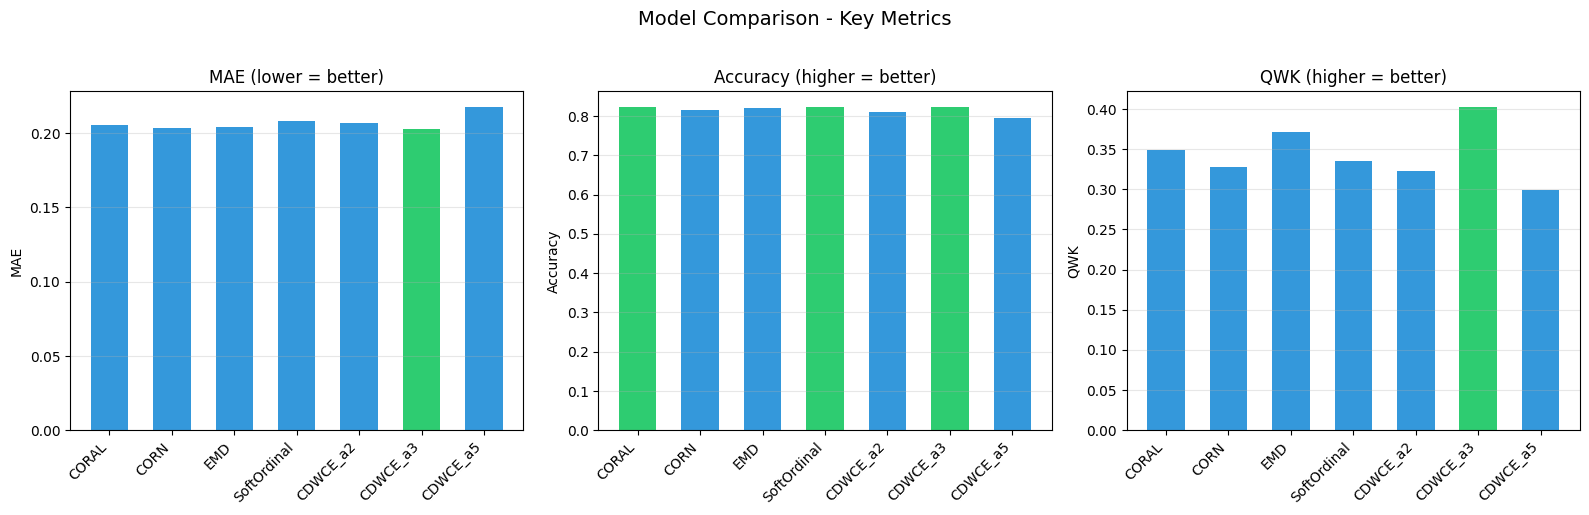

In [21]:
# Cell 4b - Model comparison table and grouped bar chart

# Build comparison DataFrame from rankable models only
rows = []
for name, res in rankable_results.items():
    rows.append(
        {
            "Model": name,
            "MAE": round(res["mae_mean"], 4),
            "Accuracy": round(res["accuracy_mean"], 4),
            "QWK": round(res["qwk_mean"], 4),
            "Spearman": round(res["spearman_mean"], 4),
            "Calibration": round(
                res["calibration"]["error_uncertainty_correlation"], 4
            ),
        }
    )

if not rows:
    raise RuntimeError("No rankable models available for comparison.")

comparison_df = pl.DataFrame(rows)
print("Model Comparison (rankable models):")
print(comparison_df)
if excluded_models:
    print(f"Excluded models (degenerate): {excluded_models}")

# Grouped bar chart for 3 key metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = comparison_df["Model"].to_list()
x = np.arange(len(model_names))
width = 0.6

# MAE (lower is better)
mae_vals = comparison_df["MAE"].to_list()
best_mae = np.nanmin(mae_vals) if np.any(np.isfinite(mae_vals)) else None
colors = [
    "#2ecc71"
    if (best_mae is not None and np.isfinite(v) and v == best_mae)
    else "#3498db"
    for v in mae_vals
]
axes[0].bar(x, mae_vals, width, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE (lower = better)")
axes[0].grid(True, alpha=0.3, axis="y")

# Accuracy (higher is better)
acc_vals = comparison_df["Accuracy"].to_list()
best_acc = np.nanmax(acc_vals) if np.any(np.isfinite(acc_vals)) else None
colors = [
    "#2ecc71"
    if (best_acc is not None and np.isfinite(v) and v == best_acc)
    else "#3498db"
    for v in acc_vals
]
axes[1].bar(x, acc_vals, width, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45, ha="right")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy (higher = better)")
axes[1].grid(True, alpha=0.3, axis="y")

# QWK (higher is better)
qwk_vals = comparison_df["QWK"].to_list()
best_qwk = np.nanmax(qwk_vals) if np.any(np.isfinite(qwk_vals)) else None
colors = [
    "#2ecc71"
    if (best_qwk is not None and np.isfinite(v) and v == best_qwk)
    else "#3498db"
    for v in qwk_vals
]
axes[2].bar(x, qwk_vals, width, color=colors)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=45, ha="right")
axes[2].set_ylabel("QWK")
axes[2].set_title("QWK (higher = better)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Model Comparison - Key Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Best model for confusion matrix: CDWCE_a3 (QWK)


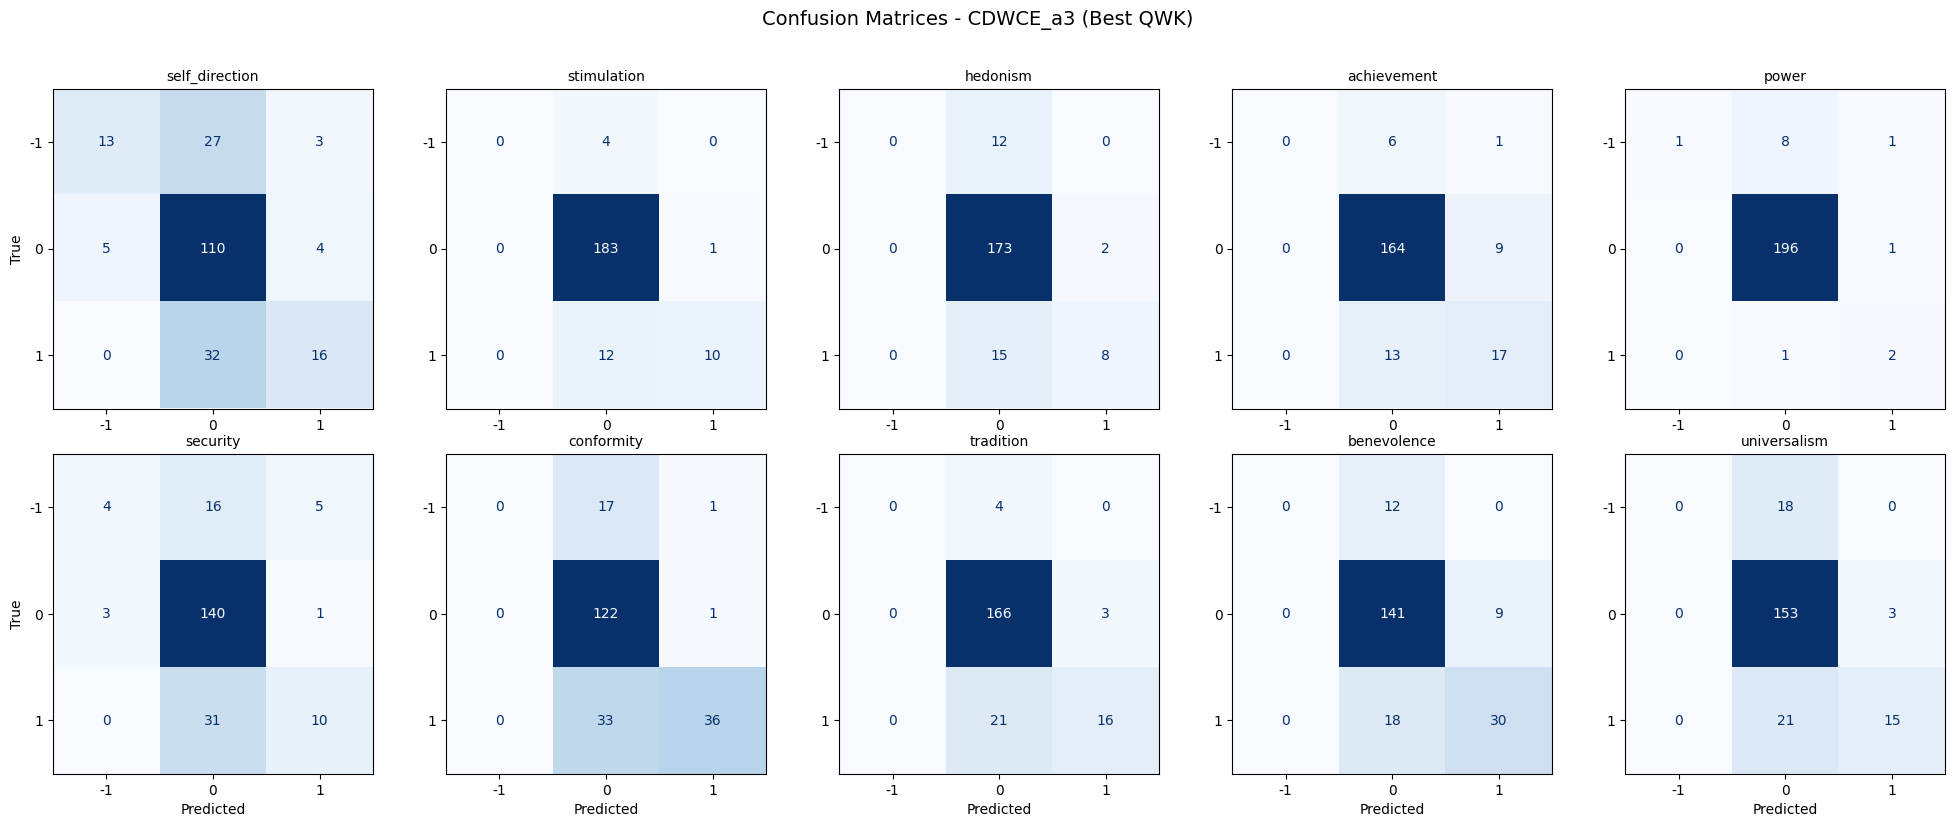


Per-Class Recall Across Models (aggregated over 10 dimensions)

Model            Recall -1   Recall 0  Recall +1   Mean minority
--------------------------------------------------------------
CORAL                 6.4%      97.4%      41.8%           24.1%
CORN                  6.0%      97.1%      40.8%           23.4%
EMD                   5.6%      96.2%      50.5%           28.0%
SoftOrdinal           6.4%      94.6%      52.0%           29.2%
CDWCE_a2              3.8%      97.3%      40.3%           22.0%
CDWCE_a3              5.6%      97.2%      46.1%           25.9%
CDWCE_a5              1.2%      98.0%      33.6%           17.4%


In [22]:
# Cell 4c - Confusion matrices for best model + per-class recall

# Find best model by finite QWK among rankable models
qwk_candidates = {
    n: rankable_results[n]["qwk_mean"]
    for n in rankable_results
    if np.isfinite(rankable_results[n].get("qwk_mean", float("nan")))
}
if qwk_candidates:
    best_model_name = max(qwk_candidates, key=qwk_candidates.get)
    best_model_reason = "QWK"
else:
    best_model_name = max(
        rankable_results, key=lambda n: rankable_results[n]["accuracy_mean"]
    )
    best_model_reason = "Accuracy fallback"

print(f"Best model for confusion matrix: {best_model_name} ({best_model_reason})")

# Plot confusion matrices for best model (2x5 grid)
res = rankable_results[best_model_name]
pred_cls = discretize_predictions(res["predictions"])
target_cls = discretize_predictions(res["targets"])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes_flat = axes.flatten()
for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    cm = confusion_matrix(target_cls[:, i], pred_cls[:, i], labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=[-1, 0, 1])
    disp.plot(ax=axes_flat[i], cmap="Blues", colorbar=False)
    axes_flat[i].set_title(dim, fontsize=10)
    axes_flat[i].set_xlabel("Predicted" if i >= 5 else "")
    axes_flat[i].set_ylabel("True" if i % 5 == 0 else "")
plt.suptitle(
    f"Confusion Matrices - {best_model_name} (Best {best_model_reason})",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Per-class recall table across all models
print(f"\n{'=' * 70}")
print("Per-Class Recall Across Models (aggregated over 10 dimensions)")
print(f"{'=' * 70}")
print(
    f"\n{'Model':<15s} {'Recall -1':>10s} {'Recall 0':>10s} "
    f"{'Recall +1':>10s} {'Mean minority':>15s}"
)
print("-" * 62)

all_recall_data = {}
for model_name, res in all_results.items():
    pred_cls = discretize_predictions(res["predictions"])
    target_cls = discretize_predictions(res["targets"])

    recall_minus1 = []
    recall_zero = []
    recall_plus1 = []

    for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
        cm = confusion_matrix(target_cls[:, i], pred_cls[:, i], labels=[-1, 0, 1])
        for c, recall_list in enumerate([recall_minus1, recall_zero, recall_plus1]):
            row_sum = cm[c].sum()
            recall = cm[c, c] / row_sum if row_sum > 0 else float("nan")
            recall_list.append(recall)

    mean_r_neg = np.nanmean(recall_minus1)
    mean_r_zero = np.nanmean(recall_zero)
    mean_r_pos = np.nanmean(recall_plus1)
    mean_minority = np.nanmean(recall_minus1 + recall_plus1)

    all_recall_data[model_name] = {
        "recall_minus1": mean_r_neg,
        "recall_zero": mean_r_zero,
        "recall_plus1": mean_r_pos,
        "mean_minority": mean_minority,
    }

    print(
        f"{model_name:<15s} {mean_r_neg:>10.1%} {mean_r_zero:>10.1%} "
        f"{mean_r_pos:>10.1%} {mean_minority:>15.1%}"
    )


In [23]:
# Cell 4d — Hedging comparison: % predictions in [-0.3, 0.3] per model

print(f"{'=' * (20 + 13 * len(all_results))}")
print("Hedging Comparison — % predictions in [-0.3, 0.3]")
print(f"{'=' * (20 + 13 * len(all_results))}")

print(f"\n{'Dimension':<20s}", end="")
for name in all_results:
    print(f" {name:>12s}", end="")
print()
print("-" * (20 + 13 * len(all_results)))

all_hedging = {}
for name, res in all_results.items():
    preds = res["predictions"]
    near_zero = ((preds > -0.3) & (preds < 0.3)).mean(axis=0)
    all_hedging[name] = near_zero

for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    print(f"{dim:<20s}", end="")
    for name in all_results:
        val = all_hedging[name][i]
        flag = "*" if val > 0.8 else " "
        print(f" {val:>11.1%}{flag}", end="")
    print()

print(f"{'MEAN':<20s}", end="")
for name in all_results:
    mean_val = all_hedging[name].mean()
    print(f" {mean_val:>11.1%} ", end="")
print()
print(f"\n* = hedging (>80% near zero)")

Hedging Comparison — % predictions in [-0.3, 0.3]

Dimension                   CORAL         CORN          EMD  SoftOrdinal     CDWCE_a2     CDWCE_a3     CDWCE_a5
---------------------------------------------------------------------------------------------------------------
self_direction             65.2%        60.0%        70.0%        49.5%        73.8%        72.4%        84.3%*
stimulation                92.9%*       94.3%*       91.4%*       92.4%*       92.4%*       93.3%*       94.8%*
hedonism                   91.9%*       91.4%*       87.1%*       92.4%*       97.6%*       91.9%*       93.3%*
achievement                81.9%*       84.8%*       86.7%*       86.7%*       88.6%*       84.3%*       89.0%*
power                      97.1%*       96.2%*       97.1%*       97.6%*       98.6%*       96.7%*       96.2%*
security                   78.6%        91.0%*       91.9%*       80.0%        83.8%*       83.3%*       91.0%*
conformity                 77.1%        72.9%        

# Section 5: Calibration Analysis (Issue #9)

**Issue 9 — Uncertainty Calibration:** Does higher MC Dropout uncertainty correspond to higher actual error? If not, uncertainty estimates are unreliable.

In [24]:
# Cell 5a - Per-dimension error-uncertainty correlation across all models

print(f"{'=' * (20 + 13 * len(all_results))}")
print("Calibration Analysis - Error-Uncertainty Spearman Correlation")
print(f"{'=' * (20 + 13 * len(all_results))}")

print(f"\n{'Dimension':<20s}", end="")
for name in all_results:
    print(f" {name:>12s}", end="")
print()
print("-" * (20 + 13 * len(all_results)))

all_calibration = {}
for name, res in all_results.items():
    preds = res["predictions"]
    tgts = res["targets"]
    uncs = res["uncertainties"]
    errs = np.abs(preds - tgts)

    cal_per_dim = {}
    positive_count = 0

    for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
        unc_dim = uncs[:, i]
        err_dim = errs[:, i]
        if np.std(unc_dim) < 1e-8 or np.std(err_dim) < 1e-8:
            corr = float("nan")
        else:
            corr, _ = stats.spearmanr(unc_dim, err_dim)
        cal_per_dim[dim] = corr
        if not np.isnan(corr) and corr > 0:
            positive_count += 1

    all_calibration[name] = {
        "per_dim": cal_per_dim,
        "global": res["calibration"]["error_uncertainty_correlation"],
        "positive_count": positive_count,
        "mean_uncertainty": res["calibration"]["mean_uncertainty"],
    }

for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    print(f"{dim:<20s}", end="")
    for name in all_results:
        corr = all_calibration[name]["per_dim"][dim]
        corr_str = f"{corr:+.3f}" if not np.isnan(corr) else "N/A"
        print(f" {corr_str:>12s}", end="")
    print()

print(f"\n{'Global correlation':<20s}", end="")
for name in all_results:
    corr = all_calibration[name]["global"]
    corr_str = f"{corr:+.3f}" if np.isfinite(corr) else "N/A"
    print(f" {corr_str:>12s}", end="")
print()
print(f"{'Positive dims':<20s}", end="")
for name in all_results:
    print(f" {all_calibration[name]['positive_count']:>10d}/10", end="")
print()
print(f"{'Mean uncertainty':<20s}", end="")
for name in all_results:
    print(f" {all_calibration[name]['mean_uncertainty']:>12.4f}", end="")
print()


Calibration Analysis - Error-Uncertainty Spearman Correlation

Dimension                   CORAL         CORN          EMD  SoftOrdinal     CDWCE_a2     CDWCE_a3     CDWCE_a5
---------------------------------------------------------------------------------------------------------------
self_direction             +0.601       +0.556       +0.487       +0.568       +0.457       +0.506       +0.273
stimulation                +0.941       +0.860       +0.885       +0.933       +0.898       +0.818       +0.738
hedonism                   +0.873       +0.851       +0.874       +0.858       +0.666       +0.722       +0.650
achievement                +0.833       +0.812       +0.793       +0.817       +0.744       +0.756       +0.683
power                      +0.938       +0.937       +0.894       +0.879       +0.881       +0.850       +0.809
security                   +0.689       +0.659       +0.611       +0.735       +0.706       +0.646       +0.567
conformity                 +0.714       +

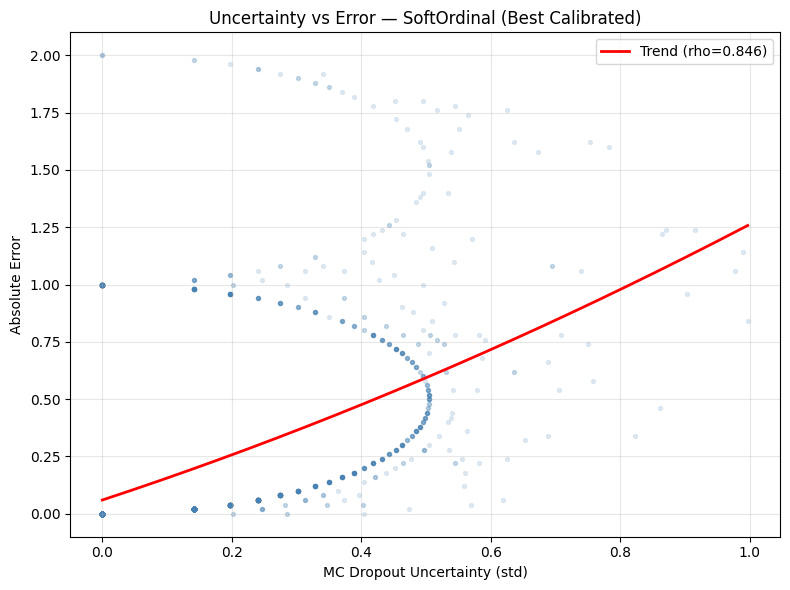

In [25]:
# Cell 5b — Calibration scatter for best-calibrated model
best_cal_model = max(all_calibration, key=lambda n: all_calibration[n]["global"])
res = all_results[best_cal_model]

unc_flat = res["uncertainties"].flatten()
err_flat = np.abs(res["predictions"] - res["targets"]).flatten()
global_corr = all_calibration[best_cal_model]["global"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(unc_flat, err_flat, alpha=0.15, s=8, color="steelblue")

finite_mask = np.isfinite(unc_flat) & np.isfinite(err_flat)
if finite_mask.sum() > 3:
    z = np.polyfit(unc_flat[finite_mask], err_flat[finite_mask], 2)
    p = np.poly1d(z)
    x_line = np.linspace(unc_flat[finite_mask].min(), unc_flat[finite_mask].max(), 200)
    ax.plot(
        x_line, p(x_line), "r-", linewidth=2, label=f"Trend (rho={global_corr:.3f})"
    )

ax.set_xlabel("MC Dropout Uncertainty (std)")
ax.set_ylabel("Absolute Error")
ax.set_title(f"Uncertainty vs Error — {best_cal_model} (Best Calibrated)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 6: Issue Scorecard

Summary of all diagnostics for before/after comparison.

In [26]:
# Cell 6.1 - Multi-model scorecard
print("=" * 90)
print("DIAGNOSTIC SCORECARD - MULTI-MODEL COMPARISON")
print("=" * 90)

# Issue #9 - Calibration
print(f"\n{'--- #9 Calibration ':-<90s}")
print(
    f"  {'Model':<15s} {'Global corr':>12s} {'Positive dims':>15s} {'Mean unc.':>12s}"
)
print(f"  {'-' * 56}")
for name in all_results:
    cal = all_calibration[name]
    global_corr = cal["global"]
    corr_str = f"{global_corr:+.3f}" if np.isfinite(global_corr) else "N/A"
    print(
        f"  {name:<15s} {corr_str:>12s} "
        f"{cal['positive_count']:>13d}/10 {cal['mean_uncertainty']:>12.4f}"
    )
print(f"  Guidance: >0.1 useful, <0 dangerous (uncertainty misleads)")

# Issue #10 - Imbalance
print(f"\n{'--- #10 Imbalance ':-<90s}")
print(f"  Overall neutral %: {neutral_pct:.1f}%")
print(
    f"  Flagged dims (>10x imbalance): {sum(1 for r in imbalance_ratios if r > 10)}/10"
)
print(f"  Unlearnable dims: {unlearnable if unlearnable else 'None'}")
print(
    f"\n  {'Model':<15s} {'Recall -1':>10s} {'Recall +1':>10s} {'Mean minority':>15s}"
)
print(f"  {'-' * 52}")
for name in all_results:
    rd = all_recall_data[name]
    print(
        f"  {name:<15s} {rd['recall_minus1']:>10.1%} "
        f"{rd['recall_plus1']:>10.1%} {rd['mean_minority']:>15.1%}"
    )
print(f"  Guidance: Minority recall near 0% = model ignores rare classes")

# Ordinal quality
print(f"\n{'--- Ordinal Quality ':-<90s}")
print(f"  {'Model':<15s} {'QWK':>8s} {'Hedging %':>10s} {'Status':>12s}")
print(f"  {'-' * 52}")
for name in all_results:
    qwk = all_results[name]["qwk_mean"]
    hedge = all_hedging[name].mean() * 100
    qwk_str = f"{qwk:.3f}" if np.isfinite(qwk) else "N/A"
    status = "EXCLUDED" if name in excluded_models else "OK"
    print(f"  {name:<15s} {qwk_str:>8s} {hedge:>9.1f}% {status:>12s}")
print(f"  Guidance: High hedging % = neutral collapse; QWK near 0 = chance")

# Issue #12 - Overfitting
print(f"\n{'--- #12 Overfitting ':-<90s}")
print(
    f"  {'Model':<15s} {'Best epoch':>12s} {'Best val loss':>15s} {'Gap at best':>12s}"
)
print(f"  {'-' * 56}")
for name, result in trained_models.items():
    h = result["history"]
    be = result["best_epoch"]
    n_ep = len(h["train_loss"])
    bvl = result["best_val_loss"]
    gap = (
        h["val_loss"][be] - h["train_loss"][be]
        if len(h["train_loss"]) > be
        else float("nan")
    )
    print(f"  {name:<15s} {be + 1:>5d}/{n_ep:<5d} {bvl:>15.4f} {gap:>+12.4f}")
print(f"  Guidance: Ratio >10x high risk; gap >0.05 suggests overfitting")

# Issue #14 - Embedding (model-independent)
print(f"\n{'--- #14 Embedding ':-<90s}")
print(f"  Encoder: {CONFIG['encoder_model']}")
print(f"  Truncated entries: {pct_truncated:.1f}%")
print(
    f"  Guidance: Gap <0.1 = poor discrimination; >5% truncation = losing information"
)


def _best_finite(results_dict, metric_name, mode="max"):
    values = []
    for model_name, result in results_dict.items():
        value = result.get(metric_name, float("nan"))
        if np.isfinite(value):
            values.append((model_name, value))

    if not values:
        return None, float("nan")

    if mode == "max":
        return max(values, key=lambda item: item[1])
    if mode == "min":
        return min(values, key=lambda item: item[1])
    raise ValueError(f"Unsupported mode: {mode}")


# Winner summary (rankable only)
print(f"\n{'--- Winner Summary (Rankable Models) ':-<90s}")
if not rankable_results:
    print("  No rankable models after health checks.")
else:
    best_qwk_model, best_qwk_value = _best_finite(
        rankable_results, "qwk_mean", mode="max"
    )
    best_acc_model, best_acc_value = _best_finite(
        rankable_results, "accuracy_mean", mode="max"
    )
    best_mae_model, best_mae_value = _best_finite(
        rankable_results, "mae_mean", mode="min"
    )

    rankable_calibration = {
        name: all_calibration[name]
        for name in rankable_results
        if name in all_calibration
    }
    cal_values = [
        (name, meta["global"])
        for name, meta in rankable_calibration.items()
        if np.isfinite(meta["global"])
    ]
    if cal_values:
        best_cal_model, best_cal_value = max(cal_values, key=lambda item: item[1])
    else:
        best_cal_model, best_cal_value = None, float("nan")

    print(
        f"  Best by QWK:         {best_qwk_model if best_qwk_model else 'N/A':<15s} "
        f"({best_qwk_value:.3f})"
        if np.isfinite(best_qwk_value)
        else "  Best by QWK:         N/A"
    )
    print(
        f"  Best by Accuracy:    {best_acc_model if best_acc_model else 'N/A':<15s} "
        f"({best_acc_value:.2%})"
        if np.isfinite(best_acc_value)
        else "  Best by Accuracy:    N/A"
    )
    print(
        f"  Best by MAE:         {best_mae_model if best_mae_model else 'N/A':<15s} "
        f"({best_mae_value:.4f})"
        if np.isfinite(best_mae_value)
        else "  Best by MAE:         N/A"
    )
    print(
        f"  Best by Calibration: {best_cal_model if best_cal_model else 'N/A':<15s} "
        f"({best_cal_value:.3f})"
        if np.isfinite(best_cal_value)
        else "  Best by Calibration: N/A"
    )

if excluded_models:
    print(f"\n  Excluded from ranking due to degeneracy: {excluded_models}")

print(f"\n{'=' * 90}")


DIAGNOSTIC SCORECARD - MULTI-MODEL COMPARISON

--- #9 Calibration -----------------------------------------------------------------------
  Model            Global corr   Positive dims    Mean unc.
  --------------------------------------------------------
  CORAL                 +0.824            10/10       0.1319
  CORN                  +0.801            10/10       0.1106
  EMD                   +0.781            10/10       0.1151
  SoftOrdinal           +0.846            10/10       0.1427
  CDWCE_a2              +0.783            10/10       0.1141
  CDWCE_a3              +0.755            10/10       0.1056
  CDWCE_a5              +0.639            10/10       0.0839
  Guidance: >0.1 useful, <0 dangerous (uncertainty misleads)

--- #10 Imbalance ------------------------------------------------------------------------
  Overall neutral %: 74.8%
  Flagged dims (>10x imbalance): 5/10
  Unlearnable dims: None

  Model            Recall -1  Recall +1   Mean minority
  --------------

# Section 7: Experiment Logging

In [ ]:
# Cell 6.2 - CDW-CE watch gates

print("=" * 90)
print("CDW-CE WATCH GATES")
print("=" * 90)
print("Targets: recall_minus1 > 0.15 AND QWK > 0.40")

watch_rows = []
for model_name, result in all_results.items():
    qwk = float(result.get("qwk_mean", float("nan")))
    recall_minus1 = float(all_recall_data[model_name]["recall_minus1"])

    pass_recall = recall_minus1 > 0.15
    pass_qwk = bool(np.isfinite(qwk) and qwk > 0.40)
    pass_joint = pass_recall and pass_qwk

    watch_rows.append(
        {
            "Model": model_name,
            "QWK": round(qwk, 4) if np.isfinite(qwk) else None,
            "RecallMinus1": round(recall_minus1, 4),
            "PassQWK": pass_qwk,
            "PassRecallMinus1": pass_recall,
            "PassJoint": pass_joint,
        }
    )

watch_df = pl.DataFrame(watch_rows).sort("Model")
print(watch_df)

passed = [row["Model"] for row in watch_rows if row["PassJoint"]]
if passed:
    print()
    print(f"PASS: Joint gate met by {passed}")
else:
    best_candidate = max(
        watch_rows,
        key=lambda row: (
            row["PassQWK"],
            row["RecallMinus1"],
            row["QWK"] if row["QWK"] is not None else float("-inf"),
        ),
    )
    print()
    print("NO JOINT PASS: no model met both thresholds.")
    print(
        "Best candidate by (PassQWK, RecallMinus1, QWK): "
        f"{best_candidate['Model']} "
        f"(QWK={best_candidate['QWK']}, RecallMinus1={best_candidate['RecallMinus1']})"
    )


CDW-CE WATCH GATES
Targets: recall_minus1 > 0.15 AND QWK > 0.40
shape: (7, 6)
┌─────────────┬────────┬──────────────┬─────────┬──────────────────┬───────────┐
│ Model       ┆ QWK    ┆ RecallMinus1 ┆ PassQWK ┆ PassRecallMinus1 ┆ PassJoint │
│ ---         ┆ ---    ┆ ---          ┆ ---     ┆ ---              ┆ ---       │
│ str         ┆ f64    ┆ f64          ┆ bool    ┆ bool             ┆ bool      │
╞═════════════╪════════╪══════════════╪═════════╪══════════════════╪═══════════╡
│ CDWCE_a2    ┆ 0.3224 ┆ 0.0376       ┆ false   ┆ false            ┆ false     │
│ CDWCE_a3    ┆ 0.4019 ┆ 0.0562       ┆ true    ┆ false            ┆ false     │
│ CDWCE_a5    ┆ 0.2997 ┆ 0.012        ┆ false   ┆ false            ┆ false     │
│ CORAL       ┆ 0.3492 ┆ 0.0637       ┆ false   ┆ false            ┆ false     │
│ CORN        ┆ 0.3284 ┆ 0.0604       ┆ false   ┆ false            ┆ false     │
│ EMD         ┆ 0.3719 ┆ 0.0559       ┆ false   ┆ false            ┆ false     │
│ SoftOrdinal ┆ 0.3351 ┆ 0.0642

In [28]:
OBSERVATIONS = ""  # Leave empty; experiment-review skill will generate observations

from src.vif.experiment_logger import log_experiment_run

logged_paths = log_experiment_run(
    config=CONFIG,
    trained_models=trained_models,
    all_results=all_results,
    all_calibration=all_calibration,
    all_hedging=all_hedging,
    all_recall_data=all_recall_data,
    n_train=n_train,
    n_val=n_val,
    n_test=n_test,
    pct_truncated=pct_truncated,
    state_dim=state_encoder.state_dim,
    observations=OBSERVATIONS.strip(),
)
print(f"\nLogged {len(logged_paths)} experiments:")
for entry in logged_paths:
    tag = "CREATED"
    print(f"  [{tag}] {entry['path']}  ({entry['run_id']})")


Logged 7 experiments:
  [CREATED] logs/experiments/runs/run_015_CORAL.yaml  (run_015)
  [CREATED] logs/experiments/runs/run_015_CORN.yaml  (run_015)
  [CREATED] logs/experiments/runs/run_015_EMD.yaml  (run_015)
  [CREATED] logs/experiments/runs/run_015_SoftOrdinal.yaml  (run_015)
  [CREATED] logs/experiments/runs/run_015_CDWCE_a2.yaml  (run_015)
  [CREATED] logs/experiments/runs/run_015_CDWCE_a3.yaml  (run_015)
  [CREATED] logs/experiments/runs/run_015_CDWCE_a5.yaml  (run_015)
